# 01 - Cleaning and EDA

Goal here: get the data into shape and figure out which patients come back within 30 days before I touch any model.

Dataset is the UCI Diabetes 130-hospital one (1999-2008), ~102k inpatient stays with diabetes coded somewhere in the visit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

# Download instructions in data/README.md
df = pd.read_csv("../data/diabetic_data.csv")
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## First look

How many visits, how many actual patients, and what does the readmission column look like.

In [2]:
print(f"Encounters: {len(df):,}")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")
print("\nReadmitted distribution:")
df["readmitted"].value_counts()

Encounters: 101,766
Unique patients: 71,518

Readmitted distribution:


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

The `readmitted` column has three values: `<30` (back within 30 days), `>30` (back later), and `NO`. I only care about the early ones, so I collapse it to a 0/1 flag.

In [3]:
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
print("Raw 30-day readmission rate: {:.2%}".format(df["readmit_30"].mean()))

Raw 30-day readmission rate: 11.16%


## Cleaning

Three decisions that actually change the answer:

1. One row per patient (their first visit). Patients repeat, and keeping every row lets the model peek at their future visits.
2. Drop anyone who died or went to hospice. They physically can't be readmitted, so those rows just lie to the label. Discharge codes 11, 13, 14, 19, 20, 21.
3. `?` becomes NaN, and I drop `weight`, `payer_code`, `medical_specialty` because they're mostly blank.

In [4]:
# 1. First encounter per patient
df = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")

# 2. Remove death / hospice discharges
death_hospice = [11, 13, 14, 19, 20, 21]
df = df[~df["discharge_disposition_id"].isin(death_hospice)]

# 3. Missing values + drop sparse / leaky columns
df = df.replace("?", np.nan)
drop_cols = ["weight", "payer_code", "medical_specialty"]
df = df.drop(columns=drop_cols)

print(f"Rows after cleaning: {len(df):,}")
print("Cleaned 30-day readmission rate: {:.2%}".format(df["readmit_30"].mean()))

Rows after cleaning: 69,973
Cleaned 30-day readmission rate: 8.97%


About 9% of the cleaned rows are positive. That imbalance is the whole reason I lean on ROC-AUC / PR-AUC later instead of accuracy.

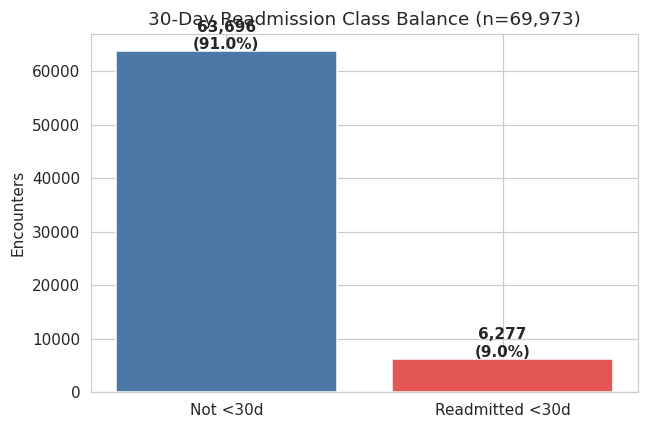

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
vc = df["readmit_30"].value_counts().sort_index()
ax.bar(["Not <30d", "Readmitted <30d"], vc.values, color=["#4C78A8", "#E45756"])
for i, v in enumerate(vc.values):
    ax.text(i, v+400, f"{v:,}\n({v/len(df):.1%})", ha="center", fontweight="bold")
ax.set_ylabel("Encounters"); ax.set_title(f"30-Day Readmission Class Balance (n={len(df):,})")
plt.tight_layout(); plt.show()

## Who actually comes back?

### By age
Older patients should be more likely to bounce back. They are.

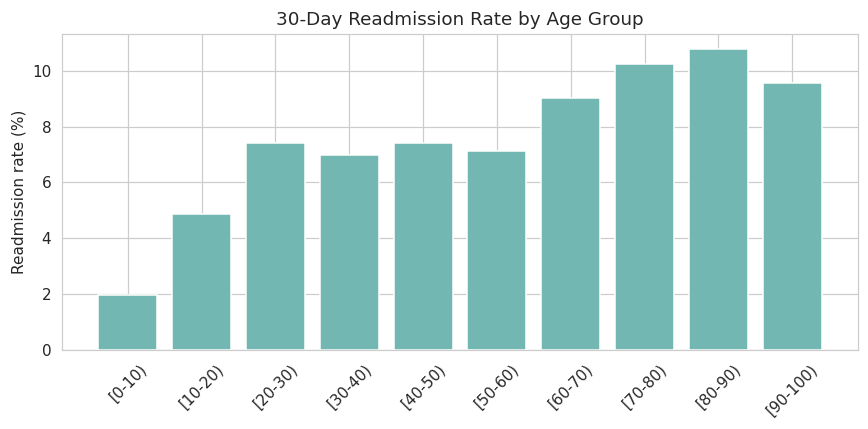

In [6]:
g = df.groupby("age")["readmit_30"].mean().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(g.index, g.values*100, color="#72B7B2")
ax.set_ylabel("Readmission rate (%)"); ax.set_title("30-Day Readmission Rate by Age Group")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### By prior inpatient visits
This one's the big tell. If you've been admitted before, you're a lot more likely to be admitted again.

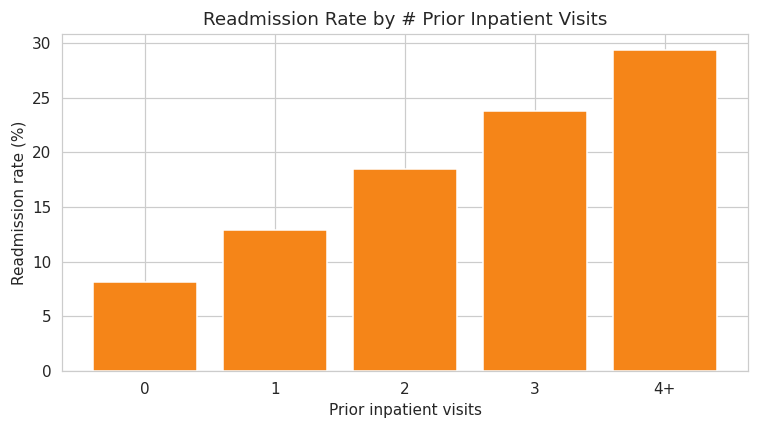

In [7]:
df["inpat_bin"] = pd.cut(df["number_inpatient"], [-1,0,1,2,3,100], labels=["0","1","2","3","4+"])
g = df.groupby("inpat_bin")["readmit_30"].mean()
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(g.index, g.values*100, color="#F58518")
ax.set_xlabel("Prior inpatient visits"); ax.set_ylabel("Readmission rate (%)")
ax.set_title("Readmission Rate by # Prior Inpatient Visits")
plt.tight_layout(); plt.show()

### Length of stay, meds, diagnoses

In [8]:
df.groupby("readmit_30")[["time_in_hospital","num_medications","number_diagnoses"]].mean().round(2)

,time_in_hospital,num_medications,number_diagnoses
readmit_30,,,
0,4.22,15.57,7.20
1,4.80,16.63,7.51


## Where this leaves me

- ~9% positive, so accuracy is a trap. Use ROC-AUC / PR-AUC and class weights.
- Things that look like they matter: prior inpatient visits, age, discharge disposition, diagnosis count, length of stay.
- Lots of the useful columns are categorical codes, so I'll one-hot them in the next notebook.

On to `02_modeling_and_evaluation.ipynb`.